# Grass Pollen Prediction for Stockholm

This notebook demonstrates pollen prediction using historical data and weather features.

In [43]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", module="IPython")

def is_google_colab() -> bool:
    if "google.colab" in str(get_ipython()):
        return True
    return False

def clone_repository() -> None:
    !git clone https://github.com/jianghongab/mlfs-book.git
    %cd mlfs-book

def install_dependencies() -> None:
    !pip install --upgrade uv
    !uv pip install --all-extras --system --requirement pyproject.toml

if is_google_colab():
    clone_repository()
    install_dependencies()
    root_dir = str(Path().absolute())
    print("Google Colab environment")
else:
    root_dir = Path().absolute()
    if root_dir.parts[-1:] == ('pollen',):
        root_dir = Path(*root_dir.parts[:-1])
    if root_dir.parts[-1:] == ('notebooks',):
        root_dir = Path(*root_dir.parts[:-1])
    root_dir = str(root_dir) 
    print("Local environment")

print(f"Root dir: {root_dir}")

# Add the root directory to the `PYTHONPATH` 
if root_dir not in sys.path:
    sys.path.append(root_dir)
    print(f"Added the following directory to the PYTHONPATH: {root_dir}")

# Set the environment variables from the file <root_dir>/.env
from mlfs import config
settings = config.HopsworksSettings(_env_file=f"{root_dir}/.env")

Local environment
Root dir: /Users/hongjiang/git/mlfs-book
HopsworksSettings initialized!


In [44]:
import pandas as pd
import hopsworks
from mlfs.airquality import util
import json
import warnings
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import great_expectations as ge
import pandas as pd
import joblib
from hsml.schema import Schema
from hsml.model_schema import ModelSchema

warnings.filterwarnings("ignore")

## 1. Connect to Hopsworks and Save Location as Secret

In [45]:
# Login to Hopsworks
project = hopsworks.login(engine="python")
fs = project.get_feature_store()
# Get secrets API
secrets = hopsworks.get_secrets_api()

# Stockholm location details
country = "Sweden"
city = "Stockholm"
street = "Österväg 17"

# Stockholm coordinates
latitude = 59.3293
longitude = 18.0686

dict_obj = {
    "country": country,
    "city": city,
    "street": street,
    "latitude": latitude,
    "longitude": longitude
}

# Convert the dictionary to a JSON string
str_dict = json.dumps(dict_obj)

# Replace any existing secret with the new value
secret = secrets.get_secret("SENSOR_LOCATION_JSON")
if secret is not None:
    secret.delete()
    print("Replacing existing SENSOR_LOCATION_JSON")

secrets.create_secret("SENSOR_LOCATION_JSON", str_dict)

print(f"Location saved: {street}, {city}, {country}")

2026-01-11 22:32:05,474 INFO: Closing external client and cleaning up certificates.
2026-01-11 22:32:05,477 INFO: Connection closed.
2026-01-11 22:32:05,478 INFO: Initializing external client
2026-01-11 22:32:05,479 INFO: Base URL: https://c.app.hopsworks.ai:443


2026-01-11 22:32:06,755 INFO: Python Engine initialized.

Logged in to project, explore it here https://c.app.hopsworks.ai:443/p/1292436
Replacing existing SENSOR_LOCATION_JSON
Secret created successfully, explore it at https://c.app.hopsworks.ai:443/account/secrets
Location saved: Österväg 17, Stockholm, Sweden


## 2. Load Historical Data

In [46]:


# Get historical pollen data
pollen_df = util.get_historical_pollen(
    start_date="2024-01-01",
    end_date="2025-12-01"
)
#pollen_df['city'] = city

# Get historical weather data
weather_df = util.get_historical_weather(
    city=city,
    start_date="2024-01-01",
    end_date="2025-12-01",
    latitude=latitude,
    longitude=longitude
)

print(f"Pollen data shape: {pollen_df.shape}")
print(f"Weather data shape: {weather_df.shape}")

Coordinates 59.3673095703125°N 18.0°E
Elevation 24.0 m asl
Timezone None None
Timezone difference to GMT+0 0 s
Pollen data shape: (471, 2)
Weather data shape: (701, 6)


In [47]:


weather_df['date'] = pd.to_datetime(weather_df['date']).dt.strftime('%Y-%m-%d %H:%M:%S')
weather_df = weather_df.rename(columns={'date': 'datetime_id'}) # Rename column

pollen_df['date'] = pd.to_datetime(pollen_df['date']).dt.strftime('%Y-%m-%d %H:%M:%S')
pollen_df = pollen_df.rename(columns={'date': 'datetime_id'}) # Rename column

#print("✅ Column name changed to datetime_str to avoid old metadata")

In [48]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 701 entries, 0 to 700
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   datetime_id                  701 non-null    object 
 1   temperature_2m_mean          701 non-null    float32
 2   precipitation_sum            701 non-null    float32
 3   wind_speed_10m_max           701 non-null    float32
 4   wind_direction_10m_dominant  701 non-null    float32
 5   city                         701 non-null    object 
dtypes: float32(4), object(2)
memory usage: 22.0+ KB


In [49]:
pollen_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 471 entries, 0 to 4
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   datetime_id   471 non-null    object
 1   grass_pollen  471 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 11.0+ KB


## 3. Merge and Feature Engineering

In [50]:
# Merge datasets (both are daily data with 'date' column)
df = pd.merge(weather_df, pollen_df, on='datetime_id', how='inner')
df = df.sort_values('datetime_id').reset_index(drop=True)


In [51]:
df['date'] = pd.to_datetime(df['datetime_id'])
# Add temporal features
df['day_of_year'] = df['date'].dt.dayofyear
df['month'] = df['date'].dt.month
df['is_high_season'] = df['day_of_year'].apply(lambda x: 1 if 140 <= x <= 250 else 0)

# Add GDD (Growing Degree Days) feature: Max(0, (T_mean - T_base))
T_base = 5.0  # Base temperature for grass growth
df['gdd_daily'] = df['temperature_2m_mean'].apply(lambda t: max(0, t - T_base))
df['gdd_cumsum'] = df.groupby(df['date'].dt.year)['gdd_daily'].cumsum()

# Add lagged weather features (yesterday's weather affects today's pollen)
df['precip_lag_1'] = df['precipitation_sum'].shift(1)
df['temp_lag_1'] = df['temperature_2m_mean'].shift(1)
df['wind_lag_1'] = df['wind_speed_10m_max'].shift(1)
df['datetime_id'] = df['date'].dt.strftime('%Y-%m-%d')

df = df.drop(columns=['date'])

df.dropna(inplace=True)
print(f"Final dataset shape: {df.shape}")
print(df.head())

Final dataset shape: (470, 15)
  datetime_id  temperature_2m_mean  precipitation_sum  wind_speed_10m_max  \
1  2024-02-10            -3.479167                0.1           20.082708   
2  2024-02-11            -3.120833                0.2           19.469975   
3  2024-02-12            -3.004167                4.0           22.737070   
4  2024-02-13            -0.906250                9.3           20.929596   
5  2024-02-14            -0.406250                0.3            8.825508   

   wind_direction_10m_dominant       city  grass_pollen  day_of_year  month  \
1                    75.478691  Stockholm             0           41      2   
2                    60.216125  Stockholm             0           42      2   
3                    63.435028  Stockholm             0           43      2   
4                    77.141968  Stockholm             0           44      2   
5                   206.956512  Stockholm             0           45      2   

   is_high_season  gdd_daily  g

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 470 entries, 1 to 470
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   datetime_id                  470 non-null    object 
 1   temperature_2m_mean          470 non-null    float32
 2   precipitation_sum            470 non-null    float32
 3   wind_speed_10m_max           470 non-null    float32
 4   wind_direction_10m_dominant  470 non-null    float32
 5   city                         470 non-null    object 
 6   grass_pollen                 470 non-null    int64  
 7   day_of_year                  470 non-null    int32  
 8   month                        470 non-null    int32  
 9   is_high_season               470 non-null    int64  
 10  gdd_daily                    470 non-null    float64
 11  gdd_cumsum                   470 non-null    float64
 12  precip_lag_1                 470 non-null    float32
 13  temp_lag_1               

In [53]:
pollen_weather_final_fg_name = "pollen_weather_final"
fs = project.get_feature_store()
pollen_weather_final_fg = fs.get_or_create_feature_group(
    name=pollen_weather_final_fg_name,
    version=1,
    primary_key=['datetime_id'], 
    description="Clean version without timestamp columns to avoid Binder Error",
    online_enabled=True
)

pollen_weather_final_fg.insert(df)

Uploading Dataframe: 10.21% | | Rows 48/470 | Elapsed Time: 00:01 | Remaining Time: 00:%3|1768167138.385|FAIL|rdkafka#producer-13| [thrd:ssl://51.161.80.189:9093/bootstrap]: ssl://51.161.80.189:9093/0: SSL handshake failed: Disconnected: connecting to a PLAINTEXT broker listener? (after 102ms in state SSL_HANDSHAKE)
Uploading Dataframe: 100.00% |█| Rows 470/470 | Elapsed Time: 00:02 | Remaining Time: 0


Launching job: pollen_weather_final_1_offline_fg_materialization
Job started successfully, you can follow the progress at 
https://c.app.hopsworks.ai:443/p/1292436/jobs/named/pollen_weather_final_1_offline_fg_materialization/executions


(Job('pollen_weather_final_1_offline_fg_materialization', 'SPARK'), None)

In [54]:
df = df.sort_values('datetime_id')
df['pollen_lag_1'] = df['grass_pollen'].shift(1)

X = df.drop(columns=['grass_pollen', 'datetime_id'], errors='ignore')
y = df['grass_pollen']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print("✅ succeed！")
print(f"feature number: {X_train.shape[1]}")
print(f"feature list: {X_train.columns.tolist()}")

✅ succeed！
feature number: 14
feature list: ['temperature_2m_mean', 'precipitation_sum', 'wind_speed_10m_max', 'wind_direction_10m_dominant', 'city', 'day_of_year', 'month', 'is_high_season', 'gdd_daily', 'gdd_cumsum', 'precip_lag_1', 'temp_lag_1', 'wind_lag_1', 'pollen_lag_1']


--- Model Evaluation Results ---
R2 Score (Goodness of Fit): 0.5925
MAE (Mean Absolute Error): 0.4865
MSE: 0.7650


<Figure size 1000x600 with 0 Axes>

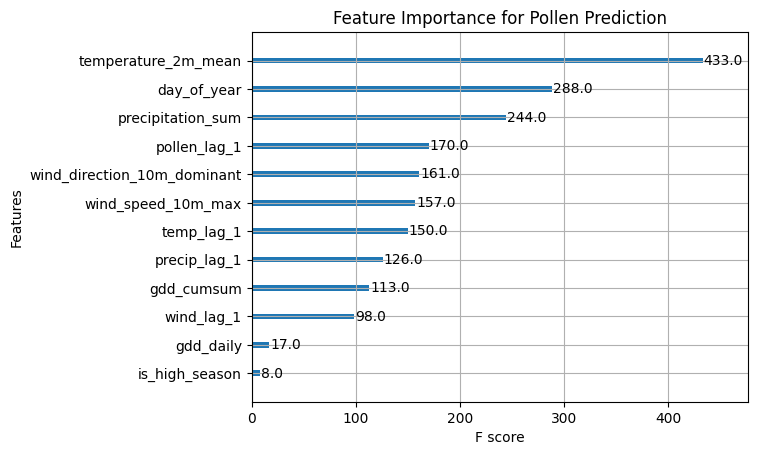

In [55]:

# 1. Remove unused features
X_train_final = X_train.drop(columns=['date', 'city'], errors='ignore')
X_test_final = X_test.drop(columns=['date', 'city'], errors='ignore')

# 2. Initialize and train XGBRegressor
model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    objective='reg:squarederror'
)

model.fit(X_train_final, y_train)

# 3. Evaluation
y_pred = model.predict(X_test_final)

print(f"--- Model Evaluation Results ---")
print(f"R2 Score (Goodness of Fit): {r2_score(y_test, y_pred):.4f}")
print(f"MAE (Mean Absolute Error): {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
# 4. Display feature importance
plt.figure(figsize=(10, 6))
xgb.plot_importance(model, importance_type='weight')
plt.title("Feature Importance for Pollen Prediction")
plt.show()

In [56]:

fv = fs.get_feature_view(name='pollen_weather_final', version=1)

# 1. Prepare model file
model_dir = "pollen_model"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)
joblib.dump(model, model_dir + "/pollen_model.pkl")

# 2. Get Model Registry instance
mr = project.get_model_registry()

# 3. Create model object
pollen_model = mr.python.create_model(
    name="grass_pollen_model", 
    metrics={"r2": r2_score(y_test, y_pred)},
    description="XGBoost Regressor for Stockholm grass pollen levels",
    feature_view=fv
)

# 4. Assign Schema (including input_schema and output_schema)
input_schema = Schema(X_train_final)
output_schema = Schema(y_train)
pollen_model.input_schema = input_schema
pollen_model.output_schema = output_schema

# 5. Save model
pollen_model.save(model_dir)

print("✅ Model saved to Hopsworks Model Registry!")

  0%|          | 0/6 [00:00<?, ?it/s]

Uploading /Users/hongjiang/git/mlfs-book/pollen/pollen_model/pollen_model.pkl: 0.000%|          | 0/207340 ela…

Model created, explore it at https://c.app.hopsworks.ai:443/p/1292436/models/grass_pollen_model/7
✅ Model saved to Hopsworks Model Registry!


## 4. Create the Feature Groups and insert the DataFrames in them

In [57]:

weather_expectation_suite = ge.core.ExpectationSuite(
    expectation_suite_name="weather_expectation_suite"
)

def expect_greater_than_zero(col):
    weather_expectation_suite.add_expectation(
        ge.core.ExpectationConfiguration(
            expectation_type="expect_column_min_to_be_between",
            kwargs={
                "column":col,
                "min_value":-0.1,
                "max_value":1000.0,
                "strict_min":True
            }
        )
    )
expect_greater_than_zero("precipitation_sum")
expect_greater_than_zero("wind_speed_10m_max")

In [58]:
try:
    weather_fg = fs.get_feature_group(name="weather", version=1)
    weather_fg.delete()
    print("Removed old weather feature group")
except:
    print("Cannot find weather feature group, will create new one")

Removed old weather feature group


In [59]:
weather_fg = fs.get_or_create_feature_group(
    name='weather',
    description='Weather characteristics of each day',
    version=1,
    primary_key=['datetime_id'],
    online_enabled=True,
    expectation_suite=weather_expectation_suite
) 
weather_fg.insert(weather_df, wait=True)


# Update feature descriptions
weather_fg.update_feature_description("datetime_id", "Date of measurement of weather")
weather_fg.update_feature_description("city", "City where weather is measured/forecast for")
weather_fg.update_feature_description("temperature_2m_mean", "Temperature in Celsius")
weather_fg.update_feature_description("precipitation_sum", "Precipitation (rain/snow) in mm")
weather_fg.update_feature_description("wind_speed_10m_max", "Wind speed at 10m above ground")
weather_fg.update_feature_description("wind_direction_10m_dominant", "Dominant Wind direction over the day")

Feature Group created successfully, explore it at 
https://c.app.hopsworks.ai:443/p/1292436/fs/1265790/fg/1911323
2026-01-11 22:32:43,446 INFO: 	2 expectation(s) included in expectation_suite.
Validation succeeded.
Validation Report saved successfully, explore a summary at https://c.app.hopsworks.ai:443/p/1292436/fs/1265790/fg/1911323


Uploading Dataframe: 100.00% |█| Rows 701/701 | Elapsed Time: 00:01 | Remaining Time: 0


Launching job: weather_1_offline_fg_materialization
Job started successfully, you can follow the progress at 
https://c.app.hopsworks.ai:443/p/1292436/jobs/named/weather_1_offline_fg_materialization/executions
2026-01-11 22:33:15,498 INFO: Waiting for execution to finish. Current state: INITIALIZING. Final status: UNDEFINED
2026-01-11 22:33:21,869 INFO: Waiting for execution to finish. Current state: RUNNING. Final status: UNDEFINED
2026-01-11 22:35:26,153 INFO: Waiting for execution to finish. Current state: AGGREGATING_LOGS. Final status: SUCCEEDED
2026-01-11 22:35:26,329 INFO: Waiting for log aggregation to finish.
2026-01-11 22:35:51,779 INFO: Execution finished successfully.


Online data ingestion progress: 0.00% |          | Rows 0/701

In [60]:
try:
    grass_pollen_fg = fs.get_feature_group(name="grass_pollen", version=1)
    grass_pollen_fg.delete()
    print("Removed old grass_pollen feature group")
except:
    print("Cannot find grass_pollen feature group, will create new one")

Removed old grass_pollen feature group


In [61]:


grass_pollen_fg = fs.get_or_create_feature_group(
    name='grass_pollen',
    description='Daily grass pollen concentration levels for Stockholm region from Pollenrapporten API',
    version=1,
    primary_key=['datetime_id'],
    online_enabled=True
)

grass_pollen_fg.insert(pollen_df)
grass_pollen_fg.update_feature_description("datetime_id", "Date of grass pollen measurement")
grass_pollen_fg.update_feature_description("grass_pollen", "Grass pollen concentration level (0-6 scale)")


Feature Group created successfully, explore it at 
https://c.app.hopsworks.ai:443/p/1292436/fs/1265790/fg/1911324


Uploading Dataframe: 100.00% |█| Rows 471/471 | Elapsed Time: 00:00 | Remaining Time: 0


Launching job: grass_pollen_1_offline_fg_materialization
Job started successfully, you can follow the progress at 
https://c.app.hopsworks.ai:443/p/1292436/jobs/named/grass_pollen_1_offline_fg_materialization/executions
